## 6-month PhD Research Proposal

Interbasin exchanges in stratified lakes

In [1]:
# imports
import ewgreaders as ewg
import xarray as xr
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from tqdm.notebook import tqdm

#### Number of CTD and Microstructure profiles and campaigns

In [14]:
n_ctd, n_microstructure = 0, 0

lake = 'Zugersee'
years = ['2025', '2026']
for year in years:
    ctd_root = f'Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/{year}/CTD'

    for date in os.listdir(ctd_root):
        if date >= '20251030':               # first field work
            dpath_L1 = os.path.join(ctd_root, date, 'L1')
            n_ctd += len(glob('*.nc', root_dir=dpath_L1))

    microstructure_root = f'Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/{year}/Microstructure'
    for date in os.listdir(microstructure_root):
        if date >= '20251030':               # first field work
           # ORGANIZE AND PROCESS ALL DATA
           pass

n_ctd, n_microstructure

(159, 0)

#### Average velocity (N and S) comparing LZC and LZN

Use `t_start` and `t_end` from LZN.  Depth range 106 (50% valid threshold from LZN) to 127 m (deepest valid from LZC).

In [254]:
lake = 'Zugersee'
year = '2026'
date = '20260114'

d_min = 106
d_max = 127

In [255]:
location = 'LZN'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, _ = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
adcp = mreader.get_adcps()[0]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(time=slice(t_start, None))
t_end = ds.time.values.max()
ds_n = ds.sel(range=slice(d_max, d_min))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZN/L0\3U420.000 ...


In [256]:
location = 'LZC'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
adcp = mreader.get_adcps()[-1]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(time=slice(t_start, t_end))
ds_c = ds.sel(range=slice(d_max, d_min))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


In [257]:
vn = ds_n.vel.sel(dir='N').to_dataframe().reset_index().drop(columns='dir')
vn['loc'] = 'LZN'

vc = ds_c.vel.sel(dir='N').to_dataframe().reset_index().drop(columns='dir')
vc['loc'] = 'LZC'

v_df = pd.concat([vn, vc], ignore_index=True)
v_df['flow_dir'] = ['N' if x > 0 else 'S' for x in v_df.vel]
v_df['vel_abs'] = v_df['vel'].abs()
v_df['loc_dir'] = v_df['loc'] + '-' + v_df['flow_dir']

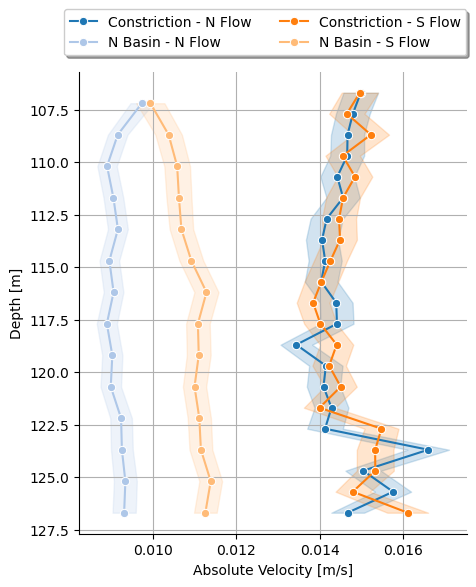

In [258]:
fig, ax = plt.subplots(figsize=(5, 6))
h_order = ['LZC-N', 'LZN-N', 'LZC-S', 'LZN-S']

sns.lineplot(v_df, x='vel_abs', y='range', orient='y', hue='loc_dir', hue_order=h_order, palette='tab20', marker='o', errorbar=('se', 1.96), ax=ax)

ax.set_xlabel('Absolute Velocity [m/s]')
ax.set_ylabel('Depth [m]')

labels = ['Constriction - N Flow', 'N Basin - N Flow', 'Constriction - S Flow', 'N Basin - S Flow']
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, labels, ncols=2, shadow=True, loc='upper center', bbox_to_anchor=(0.48, 1.15))

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

plt.show()

### Aim 1: Controlling processes and spatiotemporal variability

#### WP 1.1: Physical forcing mechanisms

Physical processes:
- Riverine input
- Differential cooling
- Differential deepening
- Internal seiche pumping

#### WP 1.2: Temporal variability

N-S velocity at the constriction as a function of depth for each day in the first two weeks of January.

In [108]:
lake = 'Zugersee'
year = '2026'
date = '20260114'

In [109]:
location = 'LZC'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
mxsc, mysc =  mreader.get_swiss_coords()
bathy = xr.open_dataset(mreader.BATHY_PATH.format(lake=lake))
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve
adcps = mreader.get_adcps()

# linear regression from known depths
sensor_depths = mreader.extract_sensor_depths()
m, b, _, _, _ = scipy.stats.linregress(sensor_depths.depth_md, sensor_depths.depth_sensor)
instruments = mreader.get_instruments(pandas=True)
instruments['depth_md'] = mreader.total_depth - instruments['mab']
instruments['depth_lr'] = m * instruments['depth_md'] + b

# use known depths where available
depth_table = pd.merge(instruments, sensor_depths, how='outer')
depth_table['depth'] = depth_table['depth_sensor'].fillna(depth_table['depth_lr']).round(1)
depth_table = depth_table.sort_values('depth')


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\12U8315.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U672.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\6D1728.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')



Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


In [110]:
all_adcp = []
for adcp in adcps:
    areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
    fpath = areader.locate_data_file('L0')
    ds = areader.load_from_L0()
    ds = ds.expand_dims(serial_id=[ds.attrs['serialnum']])
    areader.depth = depth_table.loc[depth_table['serial_id'] == adcp['serial_id'], 'depth'].iloc[0]
    ds = areader.range_to_depth(ds)
    ds['range'] = ds['range'].round(0)
    ds = areader.run_qa(ds)
    ds = ds.sel(time=slice(t_start, t_end))
    all_adcp.append(ds)

# shared time axis as mean of each instruments times
time_shared = (np.mean([ds.time.values.astype('int64') for ds in all_adcp], axis=0).astype('datetime64[ns]'))
all_adcp_aligned = [ds.assign_coords(time=time_shared) for ds in all_adcp]

# concatenate datasets and average common range bins
ds_combined = xr.concat(all_adcp_aligned, dim='range')
ds_combined = ds_combined.sortby('range')
ds_combined = ds_combined.groupby('range').mean()

# don't interplate over gap from opposite looking ADCPs in double frame
gap = np.arange(69, 73)
full_range = np.sort(np.concatenate([ds_combined.range.values, gap]))
ds_full = ds_combined.reindex(range=full_range)

# drop range bins with dubious data
bad_ranges = [68, 128, 129, 130]
ds_full = ds_full.drop_sel(range=bad_ranges)


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\12U8315.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U672.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\6D1728.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')



Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


C:\Users\herremha\AppData\Local\Temp\ipykernel_24060\2245932842.py:19: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'serial_id' ('serial_id',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.concat(all_adcp_aligned, dim='range')


In [111]:
v = ds_full.vel.sel(dir='N').mean(dim='serial_id')
v = ewg.signal.valid_depths(v, 0.95)
v_df = v.to_dataframe().reset_index().drop(columns='dir')
v_df['date'] = v_df['time'].dt.date
v_df['month'] = v_df['time'].dt.month
v_df['day'] = v_df['time'].dt.day

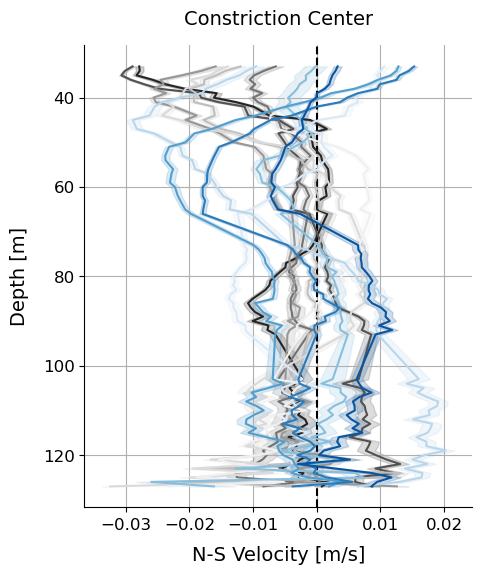

In [149]:
fig, ax = plt.subplots(figsize=(5, 6))

ax.axvline(0, color='black', linestyle='--')

sns.lineplot(v_df.query("month == 1 and day <= 7"), x='vel', y='range', orient='y', hue='date', palette='Grays_r', 
             errorbar=('se', 1), ax=ax, legend=False)
sns.lineplot(v_df.query("month == 1 and day > 7"), x='vel', y='range', orient='y', hue='date', palette='Blues', 
             errorbar=('se', 1), ax=ax, legend=False)

ax.set_xlabel('N-S Velocity [m/s]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('Constriction Center', fontsize=14, pad=15)
ax.tick_params(axis='both', labelsize=12)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

plt.show()

#### WP 1.3: Spatial variability

Use `t_start` and `t_end` from LZN (Or first week of December).  Depth range 116.5 (88% valid LZN) to 127 m (deepest valid from LZC).

In [118]:
lake = 'Zugersee'
year = '2026'
date = '20260114'

d_min = 116
d_max = 127

In [119]:
location = 'LZE'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, _ = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
adcp = mreader.get_adcps()[0]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
t_end = ds.time.values.max() + pd.Timedelta(minutes=5)       # add 5 minutes to get equal samples
ds = ds.sel(time=slice(t_start, t_end))
ds_e = ds.sel(range=slice(d_max, d_min))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZE/L0\3U16576.000 ...


In [120]:
location = 'LZC'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
adcp = mreader.get_adcps()[-1]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(time=slice(t_start, t_end))
ds_c = ds.sel(range=slice(d_max, d_min))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


In [121]:
# shared time axis as mean of each instruments times
time_shared = np.mean([ds_e.time.values.astype('int64'), ds_c.time.values.astype('int64')], axis=0).astype('datetime64[ns]')
ds_c = ds_c.assign_coords(time=time_shared)
ds_e = ds_e.assign_coords(time=time_shared)

In [122]:
uc = ds_c.vel.sel(dir='E')
vc = ds_c.vel.sel(dir='N')
speed_c = np.sqrt(uc**2 + vc**2)

ue = ds_e.vel.sel(dir='E')
ve = ds_e.vel.sel(dir='N')
speed_e = np.sqrt(ue**2 + ve**2)

# difference in flow magnitude
ds_speed = (speed_c.mean(dim='range') - speed_e.mean(dim='range')).sel(time=slice('2025-12-01', '2025-12-07'))

# 1-hour rolling average
ds_speed_ra = ds_speed.rolling(time=6, center=True).mean()

In [123]:
ds_anglec = ewg.lakes.flow_angle(ds_c)
ds_anglee = ewg.lakes.flow_angle(ds_e)

# difference in flow angle
ds_angle = (ds_anglec.mean(dim='range') - ds_anglee.mean(dim='range')).sel(time=slice('2025-12-01', '2025-12-07'))

# 1 hour rolling average
ds_angle_ra = ds_angle.rolling(time=6, center=True).mean()

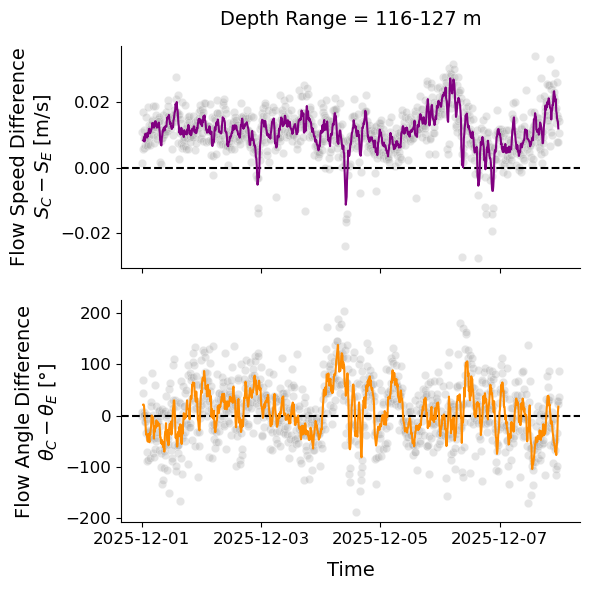

In [157]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 6), sharex=True)

# flow speed
ax[0].axhline(0, color='black', linestyle='--')
sns.scatterplot(x=ds_speed.time, y=ds_speed, alpha=0.3, color='darkgray', ax=ax[0])
sns.lineplot(x=ds_speed_ra.time, y=ds_speed_ra, color='purple', ax=ax[0])

# flow angle
ax[1].axhline(0, color='black', linestyle='--')
sns.scatterplot(x=ds_angle.time, y=ds_angle, alpha=0.3, color='darkgray', ax=ax[1])
sns.lineplot(x=ds_angle_ra.time, y=ds_angle_ra, color='darkorange', ax=ax[1])

ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_ylabel('Flow Speed Difference\n' + r'$S_{C} - S_{E}$ [m/s]', fontsize=14)
ax[1].set_ylabel('Flow Angle Difference\n' + r'$\theta_{C} - \theta_{E}$ [°]', fontsize=14)
ax[0].set_title(f'Depth Range = {d_min}-{d_max} m', fontsize=14, pad=15)
ax[1].set_xticks(ax[1].get_xticks()[::2])

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)

plt.tight_layout(h_pad=2)
plt.show()

### Aim 2: Turbulent mixing and flow-boundary interactions

#### WP 2.1: Bathymetric and topographic enhancement of turbulence

Average between FP07 sensors for each profile, then average profiles at each location.

In [158]:
lake = 'Zugersee'
year = '2026'
date = '20260113'

dpath_L2 = f'Q:Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Microstructure/{date}/L2'
fpaths = glob(f'{dpath_L2}/*.nc')

In [159]:
eps_c, chi_c, K_c = [], [], []
eps_w, chi_w, K_w = [], [], []
eps_s, chi_s, K_s = [], [], []
for fpath in fpaths:
    ds = xr.open_dataset(fpath)
    mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0) & (ds['BINNED_depth'] > 5)

    eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')
    chi = xr.concat([ds['BINNED_Xi_T1'][mask], ds['BINNED_Xi_T2'][mask]], dim='sensor').mean(dim='sensor')
    K = xr.concat([ds['BINNED_KOsbornCox_T1'][mask], ds['BINNED_KOsbornCox_T2'][mask]], dim='sensor').mean(dim='sensor')

    # VMPS
    if 'DAT_053' in fpath:
        eps_s.append(eps)
        chi_s.append(chi)
        K_s.append(K)

    # VMPC
    elif 'DAT_055' in fpath or 'DAT_059' in fpath:
        eps_c.append(eps)
        chi_c.append(chi)
        K_c.append(K)

    # VMPW
    elif 'DAT_057' in fpath:
        eps_w.append(eps)
        chi_w.append(chi)
        K_w.append(K)

In [160]:
eps_s = xr.concat(eps_s, dim='BINNED_depth').sortby('BINNED_depth')
chi_s = xr.concat(chi_s, dim='BINNED_depth').sortby('BINNED_depth')
K_s = xr.concat(K_s, dim='BINNED_depth').sortby('BINNED_depth')

eps_c = xr.concat(eps_c, dim='BINNED_depth').sortby('BINNED_depth')
chi_c = xr.concat(chi_c, dim='BINNED_depth').sortby('BINNED_depth')
K_c = xr.concat(K_c, dim='BINNED_depth').sortby('BINNED_depth')

eps_w = xr.concat(eps_w, dim='BINNED_depth').sortby('BINNED_depth')
chi_w = xr.concat(chi_w, dim='BINNED_depth').sortby('BINNED_depth')
K_w = xr.concat(K_w, dim='BINNED_depth').sortby('BINNED_depth')

In [161]:
bins_s = np.arange(0, eps_s['BINNED_depth'].max() + 5, 5)
eps_s_avg = eps_s.groupby_bins("BINNED_depth", bins_s).median()
chi_s_avg = chi_s.groupby_bins("BINNED_depth", bins_s).median()
K_s_avg = K_s.groupby_bins("BINNED_depth", bins_s).median()
bc_s = np.array([b.mid for b in eps_s_avg['BINNED_depth_bins'].values])

bins_c = np.arange(0, eps_c['BINNED_depth'].max() + 5, 5)
eps_c_avg = eps_c.groupby_bins("BINNED_depth", bins_c).median()
chi_c_avg = chi_c.groupby_bins("BINNED_depth", bins_c).median()
K_c_avg = K_c.groupby_bins("BINNED_depth", bins_c).median()
bc_c = np.array([b.mid for b in eps_c_avg['BINNED_depth_bins'].values])

bins_w = np.arange(0, eps_w['BINNED_depth'].max() + 5, 5)
eps_w_avg = eps_w.groupby_bins("BINNED_depth", bins_w).median()
chi_w_avg = chi_w.groupby_bins("BINNED_depth", bins_w).median()
K_w_avg = K_w.groupby_bins("BINNED_depth", bins_w).median()
bc_w = np.array([b.mid for b in eps_w_avg['BINNED_depth_bins'].values])

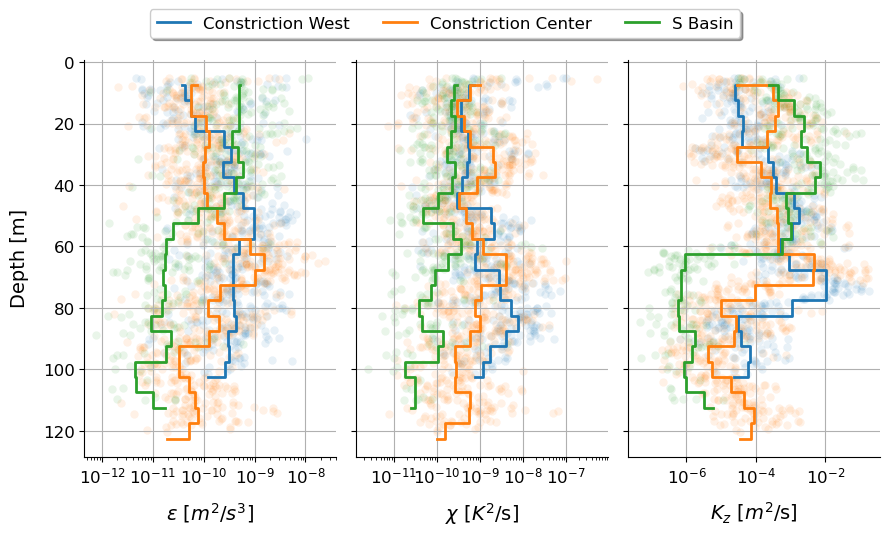

In [186]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(9, 5), sharey=True)
palette = sns.color_palette('tab10')

# epsilon
sns.scatterplot(x=eps_w, y=eps_w['BINNED_depth'], color=palette[0], alpha=0.1, ax=ax[0])
sns.lineplot(x=eps_w_avg, y=bc_w, orient='y', color=palette[0], linewidth=2, drawstyle="steps-mid", ax=ax[0], label='Constriction West')

sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color=palette[1], alpha=0.1, ax=ax[0])
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color=palette[1], linewidth=2, drawstyle="steps-mid", ax=ax[0], label='Constriction Center')

sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color=palette[2], alpha=0.1, ax=ax[0])
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color=palette[2], linewidth=2, drawstyle="steps-mid", ax=ax[0], label='S Basin')

# chi
sns.scatterplot(x=chi_w, y=chi_w['BINNED_depth'], color=palette[0], alpha=0.1, ax=ax[1])
sns.lineplot(x=chi_w_avg, y=bc_w, orient='y', color=palette[0], linewidth=2, drawstyle="steps-mid", ax=ax[1])

sns.scatterplot(x=chi_c, y=chi_c['BINNED_depth'], color=palette[1], alpha=0.1, ax=ax[1])
sns.lineplot(x=chi_c_avg, y=bc_c, orient='y', color=palette[1], linewidth=2, drawstyle="steps-mid", ax=ax[1])

sns.scatterplot(x=chi_s, y=chi_s['BINNED_depth'], color=palette[2], alpha=0.1, ax=ax[1])
sns.lineplot(x=chi_s_avg, y=bc_s, orient='y', color=palette[2], linewidth=2, drawstyle="steps-mid", ax=ax[1])

# K
sns.scatterplot(x=K_w, y=K_w['BINNED_depth'], color=palette[0], alpha=0.1, ax=ax[2])
sns.lineplot(x=K_w_avg, y=bc_w, orient='y', color=palette[0], linewidth=2, drawstyle="steps-mid", ax=ax[2])

sns.scatterplot(x=K_c, y=K_c['BINNED_depth'], color=palette[1], alpha=0.1, ax=ax[2])
sns.lineplot(x=K_c_avg, y=bc_c, orient='y', color=palette[1], linewidth=2, drawstyle="steps-mid", ax=ax[2])

sns.scatterplot(x=K_s, y=K_s['BINNED_depth'], color=palette[2], alpha=0.1, ax=ax[2])
sns.lineplot(x=K_s_avg, y=bc_s, orient='y', color=palette[2], linewidth=2, drawstyle="steps-mid", ax=ax[2])

ax[0].set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax[1].set_xlabel(r'$\chi$ [$K^{2}$/s]', fontsize=14, labelpad=10)
ax[2].set_xlabel(r'$K_{z}$ [$m^{2}$/s]', fontsize=14, labelpad=10)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

handles, labels = ax[0].get_legend_handles_labels()
ax[0].get_legend().remove()
fig.legend(handles, labels, fontsize=12, ncols=3, shadow=True, loc='upper center', bbox_to_anchor=(0.5, 1.08))

ax[0].invert_yaxis()
for i in range(len(ax)):
    ax[i].set_xscale('log')
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

plt.tight_layout()
plt.show()

#### WP: 2.2: Flow generation of turbulent mixing

In [2]:
lake = 'Zugersee'
year = '2026'
date = '20260114'

In [3]:
location = 'LZC'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
mxsc, mysc =  mreader.get_swiss_coords()
bathy = xr.open_dataset(mreader.BATHY_PATH.format(lake=lake))
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve
adcps = mreader.get_adcps()

# linear regression from known depths
sensor_depths = mreader.extract_sensor_depths()
m, b, _, _, _ = scipy.stats.linregress(sensor_depths.depth_md, sensor_depths.depth_sensor)
instruments = mreader.get_instruments(pandas=True)
instruments['depth_md'] = mreader.total_depth - instruments['mab']
instruments['depth_lr'] = m * instruments['depth_md'] + b

# use known depths where available
depth_table = pd.merge(instruments, sensor_depths, how='outer')
depth_table['depth'] = depth_table['depth_sensor'].fillna(depth_table['depth_lr']).round(1)
depth_table = depth_table.sort_values('depth')


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\12U8315.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U672.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\6D1728.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')



Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


In [4]:
all_adcp = []
for adcp in adcps:
    areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
    fpath = areader.locate_data_file('L0')
    ds = areader.load_from_L0()
    ds = ds.expand_dims(serial_id=[ds.attrs['serialnum']])
    areader.depth = depth_table.loc[depth_table['serial_id'] == adcp['serial_id'], 'depth'].iloc[0]
    ds = areader.range_to_depth(ds)
    ds['range'] = ds['range'].round(0)
    ds = areader.run_qa(ds)
    ds = ds.sel(time=slice(t_start, t_end))
    all_adcp.append(ds)

# shared time axis as mean of each instruments times
time_shared = (np.mean([ds.time.values.astype('int64') for ds in all_adcp], axis=0).astype('datetime64[ns]'))
all_adcp_aligned = [ds.assign_coords(time=time_shared) for ds in all_adcp]

# concatenate datasets and average common range bins
ds_combined = xr.concat(all_adcp_aligned, dim='range')
ds_combined = ds_combined.sortby('range')
ds_combined = ds_combined.groupby('range').mean()

# don't interplate over gap from opposite looking ADCPs in double frame
gap = np.arange(69, 73)
full_range = np.sort(np.concatenate([ds_combined.range.values, gap]))
ds_full = ds_combined.reindex(range=full_range)

# drop range bins with dubious data
bad_ranges = [68, 128, 129, 130]
ds_full = ds_full.drop_sel(range=bad_ranges)


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\12U8315.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U672.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\6D1728.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')



Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


C:\Users\herremha\AppData\Local\Temp\ipykernel_21716\2245932842.py:19: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'serial_id' ('serial_id',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.concat(all_adcp_aligned, dim='range')


In [147]:
Ri_data = []
idx = 0
lzc_locs = ["P06", "P07", "PC", "VMPC"]
years = ['2025', '2026']
for year in years:
    ctd_root = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/CTD'

    for date in tqdm(os.listdir(ctd_root)):
        if pd.to_datetime(date) > pd.to_datetime(t_start) and pd.to_datetime(date) < pd.to_datetime(t_end):
            dpath_L1 = os.path.join(ctd_root, date, 'L1')
            for p in os.listdir(dpath_L1):
                fpath = os.path.join(dpath_L1, p)
                ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
                ds = ctdreader.load_from_L1()

                if ds.attrs['Profile name'] in lzc_locs:
                    N2 = ewg.efd.brunt_vaisala_frequency(ds)

                    # shear data from 30 minutes around time of N2 profile
                    time = ds.attrs['Time of measurement (local)']
                    utc_offset = ds.attrs['Time Zone local (UTC+)']
                    t = pd.to_datetime(date + " " + time, format="%Y%m%d %H:%M") - pd.Timedelta(hours=int(utc_offset))
                    ds_sel = ds_full.sel(time=slice(t-pd.Timedelta(minutes=15), t+pd.Timedelta(minutes=15)))
                    S2 = ewg.efd.vertical_shear(ds_sel).mean(dim=['serial_id', 'time'])

                    # align N2 depths with shear bins
                    N2_depth = (N2.swap_dims({'time': 'depth'}).sortby('depth').groupby('depth').mean())
                    N2_aligned = N2_depth.sel(depth=S2.range, method='nearest').assign_coords(depth=S2.range)

                    # gradient Richardson number
                    Ri = N2_aligned / S2

                    dat = pd.DataFrame({
                        'idx': idx,
                        'N2': N2_aligned.values,
                        'S2': S2.values,
                        'Ri': Ri.values,
                        'depth': Ri.depth
                    })
                    dat[['date', 'time', 'time_utc', 'loc']] = date, time, t, ds.attrs['Profile name']
                    Ri_data.append(dat)
                    idx += 1

Ri_data = pd.concat(Ri_data, ignore_index=True)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [152]:
for (idx, time, loc), dat in Ri_data.groupby(['idx', 'time', 'loc']):
    print(idx, time, loc, dat.dropna().Ri.median())

0 11:21 P06 0.022247056751470484
1 11:45 P07 0.00979183775878981
2 12:01 P06 0.007789153969190986
3 12:26 P07 0.0017220220956490557
4 11:37 P06 0.018117336946730754
5 11:51 P07 0.008292889947799715
6 12:25 VMPC 0.03866267999041928
7 14:05 VMPC 0.08068984149437894
8 11:49 VMPC 0.013887510673074808
9 13:21 VMPC 0.015490511941911388
10 09:57 P07 0.009619192060528973
11 10:17 P06 0.04066863487240993
12 13:42 PC 0.01212850586410179
13 14:02 PC 0.02415750208525384
14 14:19 PC 0.037764010190423386
15 12:10 P07 0.04674342243295934
16 12:26 P06 0.012693894028634658
17 12:51 P06 0.00013458350988612494
18 13:08 P07 3.018377968044676e-09
19 10:47 P06 0.001821991128187955
20 11:02 P06 0.005223255800907159
21 11:17 P06 0.008180681406828122
22 17:08 P06 0.0017251841051831712
23 14:36 P07 0.002998877756101911
24 14:55 P06 6.851698072801544e-09
25 12:15 VMPC 1.464747317117661e-09
26 13:37 VMPC 1.1510765523682376e-09
27 16:23 VMPC 7.71536615773993e-09


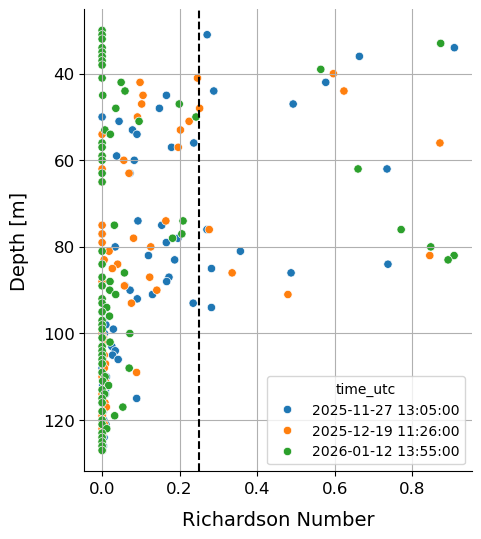

In [153]:
idx_sel = [7, 16, 24]
Ri_sel = Ri_data[Ri_data['idx'].isin(idx_sel)]

fig, ax = plt.subplots(figsize=(5, 6))

ax.axvline(0.25, color='black', linestyle='--')
sns.scatterplot(Ri_sel.query('Ri <= 1'), x='Ri', y='depth', hue='time_utc', ax=ax)

ax.set_xlabel('Richardson Number', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
plt.show()

In [352]:
data = []
constriction_locs = ["P06", "P06E", "P06W", "P07", "PC", "VMPC", "VMPW"]
years = ['2025', '2026']
for year in years:
    ctd_root = f'Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/{year}/CTD'

    for date in tqdm(os.listdir(ctd_root)):
        if date > '20251029':
            dpath_L1 = os.path.join(ctd_root, date, 'L1')
            for p in os.listdir(dpath_L1):
                fpath = os.path.join(dpath_L1, p)
                ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
                ds = ctdreader.load_from_L1()

                if ds.attrs['Profile name'] in constriction_locs:
                    # data quality
                    mask = (ds['depth'].notnull()) & (ds['Temp_qual'] == 0) & (ds['Cond_qual'] == 0) & (ds[f'DO_mg_qual'] == 0)
                    depth = ds['depth'][mask]
                    temp = ds['Temp'][mask]
                    rho = ds['rho'][mask]
                    do = ds['DO_mg'][mask]

                    # smoth density and salinity profile
                    rho = xr.DataArray(ewg.signal.rolling_average(rho, depth, 1), dims='time', coords={'time': rho['time'].values}, name='rho')

                    rho_sorted, depth_sorted = ewg.signal.order_profile(rho, depth, False)
                    thorpe_displacement = depth.values - depth_sorted.values

                    do_sorted, depth_sorted = ewg.signal.order_profile(do, depth, True)
                    do_displacement = depth.values - depth_sorted.values

                    dat = pd.DataFrame({
                        'depth': depth,
                        'temp': temp,
                        'rho': rho,
                        'do': do,
                        'thorpe_displacement': thorpe_displacement,
                        'do_displacement': do_displacement
                    })
                    dat[['loc', 'date', 'time']] = ds.attrs['Profile name'], pd.to_datetime(date), ds.attrs['Time of measurement (local)']
                    data.append(dat[dat['depth'] > 5])

data = pd.concat(data, ignore_index=True).sort_values(by=['time', 'depth'], ascending=True).reset_index(drop=True)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [369]:
data.groupby(['loc', 'date', 'time']).ngroups

56

In [364]:
for (loc, date, time), dat in data.groupby(['loc', 'date', 'time']):
    drhodz = np.gradient(dat.rho, dat.depth)
    idx = np.argmax(drhodz)
    pycnocline_depth = dat.depth.to_numpy()[idx]
    print(date, pycnocline_depth)

2025-10-30 00:00:00 114.68803312909742
2025-11-07 00:00:00 166.79922456869213
2025-11-14 00:00:00 22.568652426501583
2025-11-21 00:00:00 88.31636568856057
2025-12-16 00:00:00 20.554504782014764
2025-12-19 00:00:00 23.373818380080074
2026-01-07 00:00:00 5.130158549897914
2026-01-07 00:00:00 53.14371861038765
2026-01-07 00:00:00 53.47600212840896
2026-01-07 00:00:00 169.5116655713221
2026-01-12 00:00:00 106.47771994110335
2026-01-12 00:00:00 109.44352945282508
2026-01-14 00:00:00 9.146479090432992
2026-01-28 00:00:00 11.121124279524661
2026-01-28 00:00:00 164.92106388645976
2026-01-30 00:00:00 5.00763124991508
2026-02-27 00:00:00 6.4748990673225455
2026-02-27 00:00:00 164.63726965909035
2026-01-28 00:00:00 11.264548822415026
2026-01-28 00:00:00 39.21872256011966
2026-02-13 00:00:00 6.116817266832532
2026-02-27 00:00:00 26.72946259718895
2026-01-12 00:00:00 41.49316630044229
2026-01-28 00:00:00 5.878825864768605
2026-01-28 00:00:00 37.657532319473006
2026-02-27 00:00:00 5.433631728588461


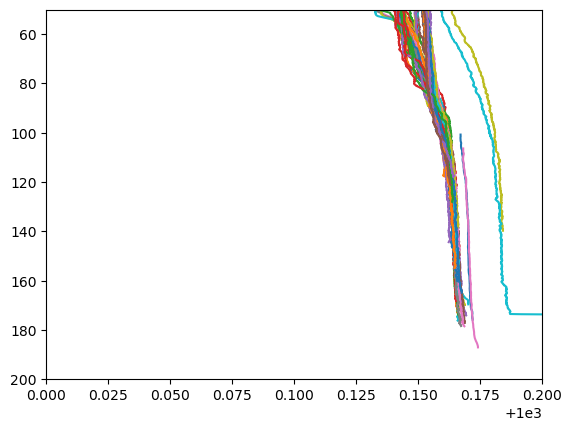

In [375]:
fig, ax = plt.subplots()
for (loc, date, time), dat in data.groupby(['loc', 'date', 'time']):
    ax.plot(dat.rho, dat.depth)
    
ax.set_ylim(50, 200)
ax.set_xlim(1000, 1000.2)
ax.invert_yaxis()
plt.show()

#### WP 2.3: Flow advection of dissipated energy and instabilities

In [154]:
lake = 'Zugersee'
year = '2026'
date = '20260213'

dpath_L1 = f'Q:Messdaten/Aphys_Hypothesis_data/{lake}/{year}/CTD/{date}/L1'

In [155]:
for p in os.listdir(dpath_L1):
    fpath = os.path.join(dpath_L1, p)
    ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
    ds = ctdreader.load_from_L1()

    if ds.attrs['Profile name'] == 'VMPS':
        # data quality
        mask = (ds['depth'].notnull()) & (ds['Temp_qual'] == 0) & (ds['Cond_qual'] == 0) & (ds[f'DO_mg_qual'] == 0)
        mask = mask & (ds['depth'] > 5)
        depth = ds['depth'][mask]
        temp = ds['Temp'][mask]
        salin = ds['SALIN'][mask]
        rho = ds['rho'][mask]
        do = ds['DO_mg'][mask]

        # smoth density and salinity profile
        rho = xr.DataArray(ewg.signal.rolling_average(rho, depth, 1), dims='time', coords={'time': rho['time'].values}, name='rho')
        salin = xr.DataArray(ewg.signal.rolling_average(salin, depth, 1), dims='time', coords={'time': salin['time'].values}, name='salin')

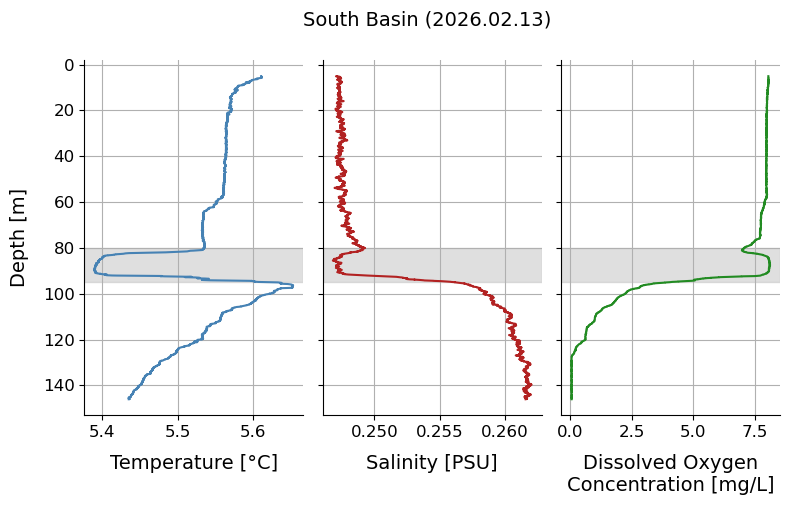

In [190]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(8, 5), sharey=True)

ax[0].plot(temp, depth, color='steelblue')
ax[1].plot(salin, depth, color='firebrick')
ax[2].plot(do, depth, color='forestgreen')

ax[0].set_xlabel('Temperature [°C]', fontsize=14, labelpad=10)
ax[1].set_xlabel('Salinity [PSU]', fontsize=14, labelpad=10)
ax[2].set_xlabel('Dissolved Oxygen\nConcentration [mg/L]', fontsize=14, labelpad=10)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

for i in range(len(ax)):
    ax[i].axhspan(80, 95, color='silver', alpha=0.5)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

fig.suptitle('South Basin (2026.02.13)', fontsize=14, x=0.54, y=1)
ax[0].invert_yaxis()
plt.tight_layout()
plt.show()

### Aim 3: Horizontal pathway for deep water renewal

#### WP 3.1: Identification of renewal events

How often does deep water renewal occur?

In [70]:
def calculate_transect_min_do(dpath_L1):
    # transect minimum
    min_do = []
    for p in os.listdir(dpath_L1):
        fpath = os.path.join(dpath_L1, p)
        
        ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
        bathy = ctdreader.load_bathymetry()
        ds = ctdreader.load_from_L1()

        # data quality
        mask = (ds['depth'].notnull()) & (ds[f'DO_mg_qual'] == 0)
        do = ds['DO_mg'][mask]
        min_do.append(do.min().item())

    return min(min_do)

In [72]:
years = ['2025', '2026']
anoxia_data = []
for year in years:
    ctd_root = f'Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/{year}/CTD'

    for date in tqdm(os.listdir(ctd_root)):
        if date > '20251029':
            dpath_L1 = os.path.join(ctd_root, date, 'L1')
            for p in os.listdir(dpath_L1):
                fpath = os.path.join(dpath_L1, p)
                ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
                ds = ctdreader.load_from_L1()

                ysc = int(ds.attrs['Y Coordinate (CH1903)']) + int(1e6)
                if ysc < 1217437:
                    min_do = calculate_transect_min_do(dpath_L1)
                    
                    # data quality
                    mask = (ds['depth'].notnull()) & (ds[f'DO_mg_qual'] == 0)
                    depth = ds['depth'][mask]
                    do = ds['DO_mg'][mask]

                    try:
                        idx = np.where(do <= min_do + 0.2)[0][0]
                        z = depth[idx].item()
                    except IndexError:
                        z = np.nan

                    anoxia_data.append({
                        'date': pd.to_datetime(date, format='%Y%m%d'),
                        'anoxic_depth': z
                    })

anoxia_data = pd.DataFrame(anoxia_data)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

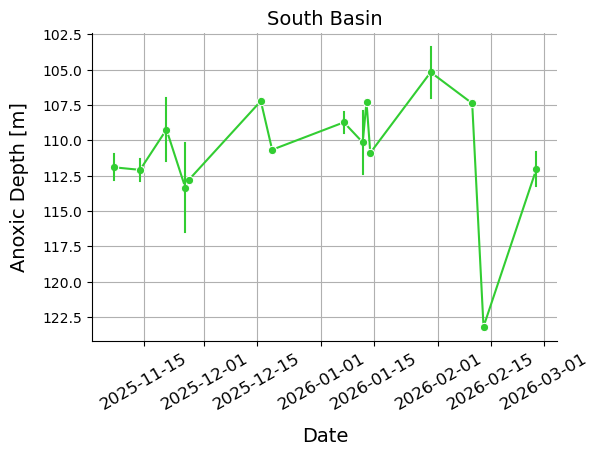

In [75]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.lineplot(anoxia_data, x='date', y='anoxic_depth', marker='o', errorbar=('se', 1), err_style='bars', color='limegreen', ax=ax)

ax.set_xlabel('Date', fontsize=14, labelpad=10)
ax.set_ylabel('Anoxic Depth [m]', fontsize=14, labelpad=10)
ax.set_title('South Basin', fontsize=14)
ax.tick_params(axis='x', rotation=30, labelsize=12)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
plt.show()

#### WP 3.2: Calculation of horizontal contribution

Deep water renewal from vertical convective circulation, horizontal interbasin exchanges, and horizontal littoral-pelagic exchanges

In [2]:
lake = 'Zugersee'
year = '2026'
date = '20260114'

t_start = '2026-01-10'
t_end = '2026-01-12'

In [3]:
location = 'LZC'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
adcp = mreader.get_adcps()[-1]
oxygen_loggers = mreader.get_oxygen_loggers()
thermistors = mreader.get_thermistors()

# linear regression from known depths
sensor_depths = mreader.extract_sensor_depths()
m, b, _, _, _ = scipy.stats.linregress(sensor_depths.depth_md, sensor_depths.depth_sensor)
instruments = mreader.get_instruments(pandas=True)
instruments['depth_md'] = mreader.total_depth - instruments['mab']
instruments['depth_lr'] = m * instruments['depth_md'] + b

# use known depths where available
depth_table = pd.merge(instruments, sensor_depths, how='outer')
depth_table['depth'] = depth_table['depth_sensor'].fillna(depth_table['depth_lr']).round(1)
depth_table = depth_table.sort_values('depth')


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\12U8315.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U672.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\6D1728.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')



Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


In [4]:
ds_chain = []
for ol in oxygen_loggers:

    oreader = ewg.o2_reader.O2Reader(ol['serial_id'], lake, location, year, date)
    fpath = os.path.join(mreader.dpath_L0, f"7450-{ol['serial_id']}/Cat.txt")
    oreader.depth = depth_table.loc[depth_table['serial_id'] == ol['serial_id'], 'depth'].iloc[0]
    ds = oreader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    #ds['d_oxygen_conc'] *= (1000/32)    # conver to umol/L
    ds_chain.append(ds)

ds_do = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


In [10]:
# time of maximum oxygen at depth
ds_do_sel = ds_do.sel(depth=ds_do.depth.min().item())
idx = ds_do_sel.d_oxygen_conc.argmax()
t0 = ds_do_sel.d_oxygen_conc[idx].time.values

np.datetime64('2026-01-10T14:24:00.000000000')

In [5]:
ds_chain = []
for t in thermistors:

    treader = ewg.thermistor_reader.ThermistorReader(t['serial_id'], lake, location, year, date)
    treader.depth = depth_table.loc[depth_table['serial_id'] == t['serial_id'], 'depth'].iloc[0]
    if treader.depth >= ds_do.depth.min().item() and treader.depth <= ds_do.depth.max().item():
        ds = treader.load_from_L0()
        ds = ds.sel(time=slice(t_start, t_end))
        ds_chain.append(ds)

ds_temp = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


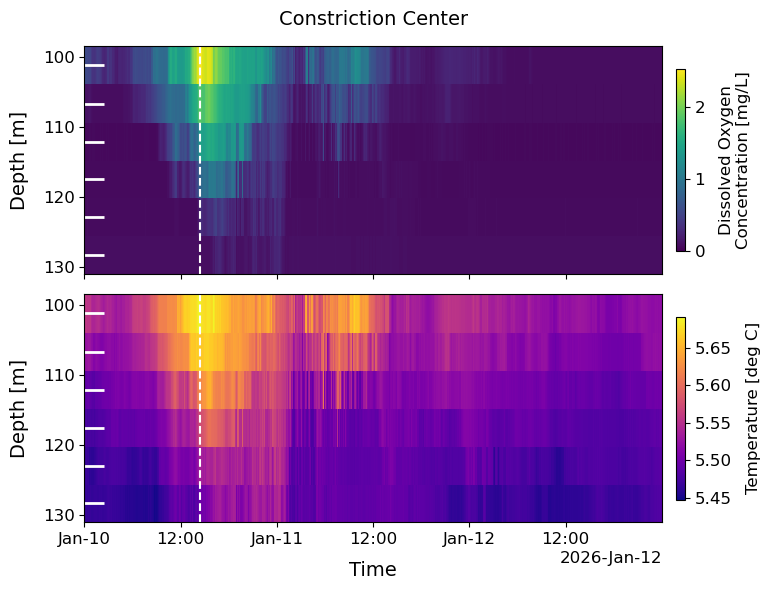

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True, sharey=True)

ax[0].axvline(t0, color='white', linestyle='--')
# oxygen and oxygen logger depths
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, cbar_kwargs={'shrink': 0.8, 'pad':0.02}, ax=ax[0])
im.colorbar.ax.tick_params(labelsize=12)
im.colorbar.ax.set_ylabel('Dissolved Oxygen\nConcentration [mg/L]', fontsize=12, labelpad=10)
for d in ds_do.depth:
    ax[0].plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax[0].get_yaxis_transform(), clip_on=False)

ax[1].axvline(t0, color='white', linestyle='--')
# temperature and thermistor depths
im = ds_temp.temp.plot(cmap='plasma', cbar_kwargs={'shrink': 0.8, 'pad':0.02}, ax=ax[1])
im.colorbar.ax.tick_params(labelsize=12)
im.colorbar.ax.set_ylabel('Temperature [° C]', fontsize=12, labelpad=10)
ax[1].xaxis.get_offset_text().set_fontsize(12)
for d in ds_temp.depth:
    ax[1].plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax[1].get_yaxis_transform(), clip_on=False)

ax[0].set_xlabel('')
ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[1].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[0].set_title('Constriction Center', fontsize=14, pad=15)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='both', labelsize=12)
ax[0].invert_yaxis()

plt.tight_layout()
plt.show()

In [12]:
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(range=slice(ds_do.depth.max().item(), ds_do.depth.min().item()))
ds_adcp = ds.sel(time=slice(t0, t_end))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


In [55]:
v_avg = ds_adcp.vel.sel(dir='N').mean(dim='range')
v_ra = v_avg.rolling(time=6, center=True).mean()    # 1-hour rolling average
dt = ds_adcp.time.diff('time').astype('timedelta64[s]').astype(float)
dt = dt.reindex(time=ds.time, method='pad')
r = (v_avg * dt).cumsum('time')

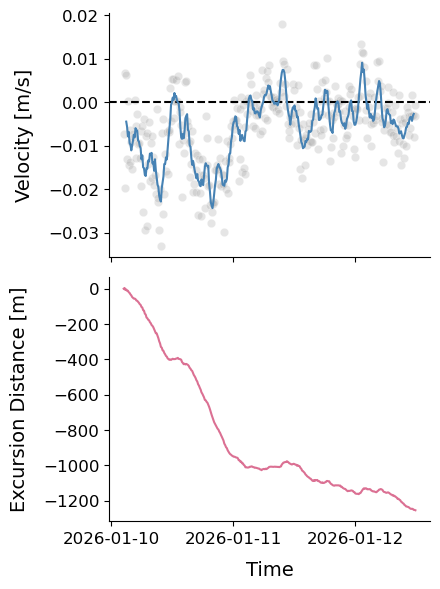

In [68]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(4.5, 6), sharex=True)

ax[0].axhline(0, color='black', linestyle='--')
sns.scatterplot(x=v_avg.time, y=v_avg, alpha=0.3, color='darkgray', ax=ax[0])
sns.lineplot(x=v_ra.time, y=v_ra, color='steelblue', ax=ax[0])

sns.lineplot(x=r.time, y=r, color='palevioletred', ax=ax[1])

ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[1].set_xticks(ax[1].get_xticks()[::4])
ax[0].set_ylabel('Velocity [m/s]', fontsize=14, labelpad=10)
ax[1].set_ylabel('Excursion Distance [m]', fontsize=14, labelpad=10)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='both', labelsize=12)

ax[0].spines[['right', 'top']].set_visible(False)
ax[1].spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

### Methodology

In [2]:
bathy_zug = xr.open_dataset('Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/bathymetry.nc')

In [32]:
# planned locations
locs_zug = pd.DataFrame({
    'name': ["P1", "P2", "P3", "VMPN", "P05'", "P05''", "LZC", "LZW", "LZE", "P7", "P8", "P9", "VMPS", "P10", "P11", "P12"],
    'xsc': [679803, 679803, 679663, 679250, 679322, 679711, 680090, 679884, 680328, 680150, 680223, 680409, 680600, 680814, 681350, 681909],
    'ysc': [224100, 222690, 221650, 220433, 219531, 219097, 218816, 218764, 218866, 218462, 218126, 217437, 216834, 216239, 214957, 213760],
    'mooring': [False, False, False, False, True, False, True, True, True, False, False, True, False, False, False, False],
    'microstructure': [False, False, False, True, False, False, True, True, True, False, False, False, True, False, False, False],
    'water_sample': [False, False, False, True, False, False, True, False, False, False, False, False, True, False, False, False]
})
# VMPS xsc = 680442
locs_zug['xsc'] += int(2e6)
locs_zug['ysc'] += int(1e6)
locs_zug['total_depth'] = [bathy_zug.sel(xsc=row.xsc, ysc=row.ysc).depth.item() for _, row in locs_zug.iterrows()]

locs_zug

,name,xsc,ysc,mooring,microstructure,water_sample,total_depth
0,P1,2679803,1224100,False,False,False,48.48001
1,P2,2679803,1222690,False,False,False,70.04001
2,P3,2679663,1221650,False,False,False,98.44000
3,VMPN,2679250,1220433,False,True,True,120.45999
4,P05',2679322,1219531,True,False,False,135.72000
5,P05'',2679711,1219097,False,False,False,168.43001
6,LZC,2680090,1218816,True,True,True,177.62001
7,LZW,2679884,1218764,True,True,False,132.09000
8,LZE,2680328,1218866,True,True,False,138.49002
9,P7,2680150,1218462,False,False,False,185.75000


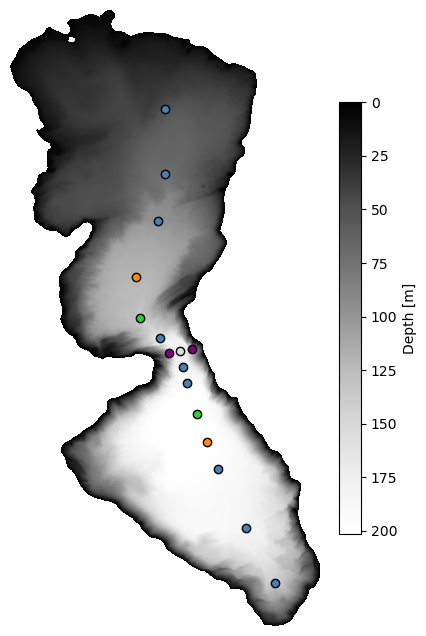

In [33]:
fig, ax = plt.subplots(figsize=(5, 8))

im = ax.pcolormesh(bathy_zug['xsc'], bathy_zug['ysc'], bathy_zug['depth'], cmap='Greys_r', vmin=0)
cbar = fig.colorbar(im, shrink=0.7, label='Depth [m]', ax=ax)
cbar.ax.invert_yaxis()

# fieldwork locations
for _, row in locs_zug.iterrows():
    if row['mooring'] and row['microstructure'] and row['water_sample']:
        color = 'gainsboro'
    elif row['mooring'] and row['microstructure']:
        color = 'purple'
    elif row['mooring']:
        color = 'limegreen'
    elif row['microstructure'] and row['water_sample']:
        color = 'darkorange'
    else:
        color = 'steelblue'

    ax.scatter(row.xsc, row.ysc, c=color, edgecolor='black')
    #ax.annotate(row['name'], (row.xsc, row.ysc), color='red', xytext=(3, 0), textcoords='offset points')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.show()

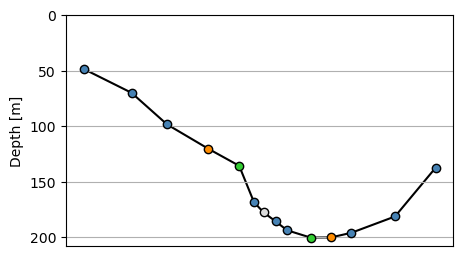

In [47]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.lineplot(locs_zug[~locs_zug['name'].isin(['LZW', 'LZE'])], x='ysc', y='total_depth', color='black', marker=None, zorder=1, ax=ax)

# fieldwork locations
for _, row in locs_zug.iterrows():
    if row['name'] in ['LZW', 'LZE']:
        continue
    elif row['mooring'] and row['microstructure'] and row['water_sample']:
        color = 'gainsboro'
    elif row['mooring'] and row['microstructure']:
        color = 'purple'
    elif row['mooring']:
        color = 'limegreen'
    elif row['microstructure'] and row['water_sample']:
        color = 'darkorange'
    else:
        color = 'steelblue'

    ax.scatter(row.ysc, row.total_depth, c=color, edgecolor='black', zorder=2)

ax.set_xlabel('')
ax.set_ylabel('Depth [m]')
ax.set_xticks([])

ax.set_ylim(0, None)
ax.invert_xaxis()
ax.invert_yaxis()
#ax.spines[['right', 'top']].set_visible(False)
ax.grid(True, zorder=0)
plt.show()

In [19]:
def read_swissbathy_asc(filename):

    header = {}

    with open(filename) as f:
        for _ in range(6):
            key, value = f.readline().split()
            header[key.lower()] = float(value)

    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    x0 = header["xllcorner"]
    y0 = header["yllcorner"]
    dx = header["cellsize"]
    nodata = header["nodata_value"]

    data = np.flipud(np.loadtxt(filename, skiprows=6))

    x = x0 + dx*np.arange(ncols)
    y = y0 + dx*np.arange(nrows)

    data[data == nodata] = np.nan

    return xr.DataArray(
        data,
        dims=("ysc","xsc"),
        coords={"xsc":x.astype(int), "ysc":y.astype(int)}
    )

In [20]:
import glob
import numpy as np

files = sorted(glob.glob('../../../data/lake_lucerne/bathymetry/*.asc'))

tiles = [read_swissbathy_asc(f) for f in files]

In [21]:
import xarray as xr

bathymetry = xr.combine_by_coords(tiles)
ds = bathymetry.to_dataset(name="depth")
ds

C:\Users\herremha\AppData\Local\Temp\ipykernel_6676\4051432450.py:3: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'xsc' ('xsc',) The recommendation is to set join explicitly for this case.
  bathymetry = xr.combine_by_coords(tiles)


<xarray.Dataset> Size: 5GB
Dimensions:  (xsc: 26497, ysc: 21421)
Coordinates:
  * xsc      (xsc) int64 212kB 2663921 2663922 2663923 ... 2690416 2690417
  * ysc      (ysc) int64 171kB 1193664 1193665 1193666 ... 1215083 1215084
Data variables:
    depth    (ysc, xsc) float64 5GB nan nan nan nan nan ... nan nan nan nan nan

In [27]:
lake_level = 434.0

# Convert elevation → depth
ds["depth"] = lake_level - ds["depth"]

# Remove land
ds["depth"] = ds["depth"].where(ds["depth"] > 0)

ds

<xarray.Dataset> Size: 5GB
Dimensions:  (xsc: 26497, ysc: 21421)
Coordinates:
  * xsc      (xsc) int64 212kB 2663921 2663922 2663923 ... 2690416 2690417
  * ysc      (ysc) int64 171kB 1193664 1193665 1193666 ... 1215083 1215084
Data variables:
    depth    (ysc, xsc) float64 5GB nan nan nan nan nan ... nan nan nan nan nan

In [25]:
import matplotlib.pyplot as plt

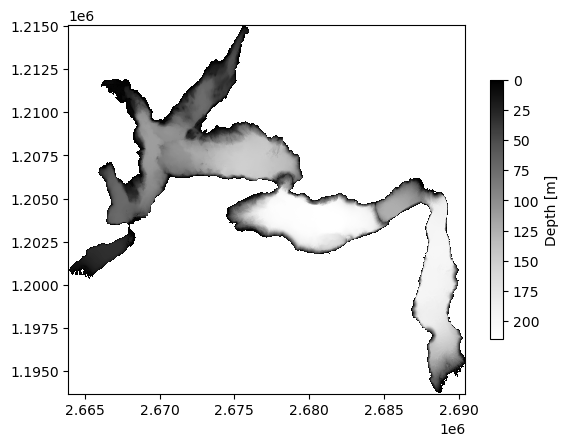

In [28]:
fig, ax = plt.subplots()

im = ax.pcolormesh(ds['xsc'], ds['ysc'], ds['depth'], cmap='Greys_r', vmin=0)
cbar = fig.colorbar(im, shrink=0.7, label='Depth [m]', ax=ax)
cbar.ax.invert_yaxis()

plt.show()

In [29]:
ds.to_netcdf('../../../data/lake_lucerne/bathymetry/lucerne_bathy.nc')